# DoorDash S&O Case Study — Delivery Operations Analysis
**Analyst:** [Your Name] | **Date:** June 2024 | **Dataset:** ~20,000 orders (1-month sample)

---

## Executive Summary

DoorDash operates a **three-sided marketplace** connecting Customers, Dashers, and Merchants. This analysis examines one month of delivery data across 56 markets to identify operational inefficiencies and revenue opportunities.

### Key Findings at a Glance
| Dimension | Finding | Severity |
|-----------|---------|----------|
| Delivery Speed | Avg 29.6 min; P90 hits 49 min — 12% of orders exceed 45 min | Medium |
| Merchant Prep | Restaurant prep (~0.7 min) is not the bottleneck — driver pickup wait (~13 min) is | High |
| Revenue | Top 2 regions (Scranton, SF) drive >30% of GOV — concentration risk | Medium |
| Refunds | ~1.4% refund rate — low overall, but 3 regions are 2–3× the average | Medium |
| Discounts | Only 8% of orders are discounted; discounted AOV ($35.81) < non-discounted ($36.42) — low ROI | High |

### Top 3 Recommendations
1. **Fix driver pickup wait** (avg 13 min) — the single largest delay lever across all markets
2. **Audit high-refund regions** (Traverse City, Muncie, Whistler) — 3–4× above average
3. **Kill blanket discounts** — no AOV lift; redirect spend to Dasher peak-hour incentives

---
> **Assumptions documented in Section 1. Dataset is UTC; analysis kept in UTC with note on local-time interpretation.**


## Stated Assumptions

| # | Assumption | Rationale |
|---|-----------|-----------|
| A1 | On-time delivery = ≤ 45 minutes end-to-end | Industry benchmark; DoorDash publicly targets ~30 min avg |
| A2 | Rows with `ORDER_TOTAL` = 0 or null = cancelled/incomplete orders | No revenue impact; excluded from financial KPIs |
| A3 | `total_delivery_min` > 240 min = data entry errors or extreme outliers | 4-hour delivery not operationally plausible |
| A4 | `driver_pickup_min` < 0 = timestamp recording error | Physically impossible; 3 rows removed |
| A5 | `DISCOUNT_AMOUNT` < 0 = data entry error | Zeroed out (2 rows) |
| A6 | Timestamps are UTC as stated in brief | No regional TZ conversion applied |
| A7 | Dashers with < 10 deliveries in the month excluded from efficiency analysis | Too few deliveries for reliable averages |
| A8 | "Scheduled" orders (IS_ASAP = False) treated as pre-planned, not late | Dataset has only 362 scheduled orders (~1.9%) |


## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── UPDATE THIS PATH to your CSV location ──
DATA_PATH = '2024 Case Study S&O Exercise - Candidate View - Sheet1 (1).csv'
# Original filename: '2024 Case Study S&O Exercise - Candidate View - Sheet1 (1).csv'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Clean Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Raw shape: (20000, 13)
Columns: ['CUSTOMER_PLACE_ORDER_DATETIME', 'PLACED_ORDER_WITH_RESTAURANT_DATETIME', 'DRIVER_AT_RESTAURANT_DATETIME', 'DELIVERED_TO_CUSTOMER_DATETIME', 'DRIVER_ID', 'RESTAURANT_ID', 'CUSTOMER_ID', 'DELIVERY_REGION', 'IS_ASAP', 'ORDER_TOTAL', 'DISCOUNT_AMOUNT', 'TIP_AMOUNT', 'REFUNDED_AMOUNT']


,CUSTOMER_PLACE_ORDER_DATETIME,PLACED_ORDER_WITH_RESTAURANT_DATETIME,DRIVER_AT_RESTAURANT_DATETIME,DELIVERED_TO_CUSTOMER_DATETIME,DRIVER_ID,RESTAURANT_ID,CUSTOMER_ID,DELIVERY_REGION,IS_ASAP,ORDER_TOTAL,DISCOUNT_AMOUNT,TIP_AMOUNT,REFUNDED_AMOUNT
0,9/20/2024 22:08:51,9/20/2024 22:08:52,9/20/2024 22:16:03,9/20/2024 22:31:23,36828872.0,11000,22130617,San Francisco,True,$32.38,$0.00,$4.50,$0.00
1,9/21/2024 1:50:46,9/21/2024 1:50:46,9/21/2024 2:14:55,9/21/2024 2:41:15,33495972.0,11000,46519725,San Francisco,True,$14.44,$2.99,$1.00,$0.00
2,9/21/2024 1:15:33,9/21/2024 1:15:33,9/21/2024 1:34:20,9/21/2024 1:57:22,29473770.0,11000,9410091,San Francisco,True,$59.67,$0.00,$7.00,$0.00


In [3]:
df = df_raw.copy()

# 1a. Parse timestamps (UTC)
dt_cols = [
    'CUSTOMER_PLACE_ORDER_DATETIME',
    'PLACED_ORDER_WITH_RESTAURANT_DATETIME',
    'DRIVER_AT_RESTAURANT_DATETIME',
    'DELIVERED_TO_CUSTOMER_DATETIME'
]
for col in dt_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

# 1b. Strip $ and parse money columns
money_cols = ['ORDER_TOTAL', 'DISCOUNT_AMOUNT', 'TIP_AMOUNT', 'REFUNDED_AMOUNT']
for col in money_cols:
    df[col] = df[col].astype(str).str.replace('[$,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 1c. Derive time segments (minutes)
df['restaurant_prep_min'] = (df['PLACED_ORDER_WITH_RESTAURANT_DATETIME'] - df['CUSTOMER_PLACE_ORDER_DATETIME']).dt.total_seconds() / 60
df['driver_pickup_min']   = (df['DRIVER_AT_RESTAURANT_DATETIME']         - df['PLACED_ORDER_WITH_RESTAURANT_DATETIME']).dt.total_seconds() / 60
df['last_mile_min']       = (df['DELIVERED_TO_CUSTOMER_DATETIME']         - df['DRIVER_AT_RESTAURANT_DATETIME']).dt.total_seconds() / 60
df['total_delivery_min']  = (df['DELIVERED_TO_CUSTOMER_DATETIME']         - df['CUSTOMER_PLACE_ORDER_DATETIME']).dt.total_seconds() / 60

# 1d. Time features
df['order_hour'] = df['CUSTOMER_PLACE_ORDER_DATETIME'].dt.hour
df['order_dow']  = df['CUSTOMER_PLACE_ORDER_DATETIME'].dt.day_name()
df['order_date'] = df['CUSTOMER_PLACE_ORDER_DATETIME'].dt.date

print('Data types after cleaning:')
print(df.dtypes)
print('\nCleaning done ✓')

Data types after cleaning:
CUSTOMER_PLACE_ORDER_DATETIME            datetime64[ns, UTC]
PLACED_ORDER_WITH_RESTAURANT_DATETIME    datetime64[ns, UTC]
DRIVER_AT_RESTAURANT_DATETIME            datetime64[ns, UTC]
DELIVERED_TO_CUSTOMER_DATETIME           datetime64[ns, UTC]
DRIVER_ID                                            float64
RESTAURANT_ID                                          int64
CUSTOMER_ID                                            int64
DELIVERY_REGION                                       object
IS_ASAP                                                 bool
ORDER_TOTAL                                          float64
DISCOUNT_AMOUNT                                      float64
TIP_AMOUNT                                           float64
REFUNDED_AMOUNT                                      float64
restaurant_prep_min                                  float64
driver_pickup_min                                    float64
last_mile_min                                        float

## 2. Data Quality Check

In [4]:
# ── 2a. Missing Values ──
missing       = df.isnull().sum()
missing_pct   = (missing / len(df) * 100).round(2)
quality_df    = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
quality_df    = quality_df[quality_df['missing_count'] > 0].sort_values('missing_%', ascending=False)

print('=== Missing Values ===')
print(quality_df)
print(f'\nTotal rows: {len(df):,} | Rows with any null: {df.isnull().any(axis=1).sum():,}')

=== Missing Values ===
                                       missing_count  missing_%
DRIVER_ID                                        457       2.28
DRIVER_AT_RESTAURANT_DATETIME                    438       2.19
driver_pickup_min                                438       2.19
last_mile_min                                    438       2.19
DELIVERED_TO_CUSTOMER_DATETIME                   436       2.18
total_delivery_min                               436       2.18
ORDER_TOTAL                                      187       0.94
DISCOUNT_AMOUNT                                  187       0.94
TIP_AMOUNT                                       187       0.94
REFUNDED_AMOUNT                                  187       0.94
PLACED_ORDER_WITH_RESTAURANT_DATETIME              7       0.03
restaurant_prep_min                                7       0.03

Total rows: 20,000 | Rows with any null: 459


In [5]:
# ── 2b. Duplicate Analysis ──
total_dupes   = df.duplicated().sum()
subset_dupes  = df.duplicated(subset=['CUSTOMER_ID','RESTAURANT_ID','CUSTOMER_PLACE_ORDER_DATETIME']).sum()

print(f'=== Duplicate Analysis ===')
print(f'Exact duplicate rows (all columns):           {total_dupes}')
print(f'Logical duplicates (same customer+restaurant+time): {subset_dupes}')

if subset_dupes > 0:
    dupe_rows = df[df.duplicated(subset=['CUSTOMER_ID','RESTAURANT_ID','CUSTOMER_PLACE_ORDER_DATETIME'], keep=False)]
    print(f'\nSample logical duplicate rows:')
    print(dupe_rows.head(4)[['CUSTOMER_ID','RESTAURANT_ID','CUSTOMER_PLACE_ORDER_DATETIME','ORDER_TOTAL']])
else:
    print('\n No duplicates detected — dataset appears deduplicated')

=== Duplicate Analysis ===
Exact duplicate rows (all columns):           0
Logical duplicates (same customer+restaurant+time): 0

 No duplicates detected — dataset appears deduplicated


In [6]:
# ── 2c. Data Type & Value Issues ──
print('=== Data Integrity Checks ===')

neg_pickup    = (df['driver_pickup_min'] < 0).sum()
neg_discount  = (df['DISCOUNT_AMOUNT']   < 0).sum()
neg_total_del = (df['total_delivery_min'] < 0).sum()
zero_order    = (df['ORDER_TOTAL'] == 0).sum()

print(f'Negative driver_pickup_min:  {neg_pickup}   → (Assumption A4: timestamp error, remove)')
print(f'Negative DISCOUNT_AMOUNT:    {neg_discount}  → (Assumption A5: data entry error, zero out)')
print(f'Negative total_delivery_min: {neg_total_del} → (remove)')
print(f'ORDER_TOTAL = 0:             {zero_order}  → (Assumption A2: cancelled, exclude)')

# Apply fixes (Assumptions A2, A4, A5)
df['DISCOUNT_AMOUNT'] = df['DISCOUNT_AMOUNT'].clip(lower=0)

df_clean = df[
    (df['total_delivery_min']  > 0) &
    (df['total_delivery_min']  < 240) &
    (df['ORDER_TOTAL']         > 0) &
    (df['driver_pickup_min'].isna() | (df['driver_pickup_min'] >= 0))
].copy()

print(f'\nRows before cleaning: {len(df):,}')
print(f'Rows after  cleaning: {len(df_clean):,}  (dropped {len(df)-len(df_clean):,})')

=== Data Integrity Checks ===
Negative driver_pickup_min:  3   → (Assumption A4: timestamp error, remove)
Negative DISCOUNT_AMOUNT:    47  → (Assumption A5: data entry error, zero out)
Negative total_delivery_min: 0 → (remove)
ORDER_TOTAL = 0:             430  → (Assumption A2: cancelled, exclude)

Rows before cleaning: 20,000
Rows after  cleaning: 19,346  (dropped 654)


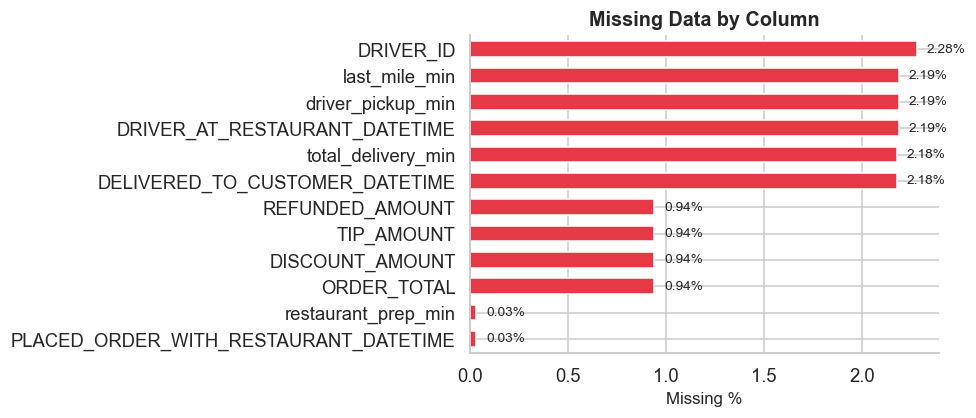


 Insight: ~2.2% of rows are missing delivery completion data — likely driver no-shows or cancelled mid-flow.


In [7]:
# ── 2d. Missing value bar chart ──
fig, ax = plt.subplots(figsize=(9, 4))
bars = quality_df['missing_%'].sort_values().plot(kind='barh', ax=ax, color='#E63946', width=0.6)
ax.set_xlabel('Missing %', fontsize=11)
ax.set_title('Missing Data by Column', fontsize=13, fontweight='bold')
for i, v in enumerate(quality_df['missing_%'].sort_values()):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('\n Insight: ~2.2% of rows are missing delivery completion data — likely driver no-shows or cancelled mid-flow.')

## 3. Outlier Analysis

In [8]:
# ── 3a. IQR-based outlier detection on key numeric columns ──
outlier_cols = ['ORDER_TOTAL', 'total_delivery_min', 'restaurant_prep_min',
                'driver_pickup_min', 'last_mile_min', 'TIP_AMOUNT']

outlier_summary = []
for col in outlier_cols:
    s = df_clean[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR': round(IQR,2), 'Lower Bound': round(lower,2),
        'Upper Bound': round(upper,2), 'Outliers (n)': n_out,
        'Outlier %': round(n_out/len(s)*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print('=== Outlier Detection (IQR Method) ===')
print(outlier_df.to_string(index=False))

=== Outlier Detection (IQR Method) ===
             Column    Q1    Q3   IQR  Lower Bound  Upper Bound  Outliers (n)  Outlier %
        ORDER_TOTAL 22.73 43.26 20.53        -8.06        74.05          1073       5.55
 total_delivery_min 19.48 36.05 16.56        -5.36        60.89           607       3.14
restaurant_prep_min  0.00  0.02  0.02        -0.02         0.04           351       1.81
  driver_pickup_min  6.30 17.02 10.72        -9.77        33.09           732       3.78
      last_mile_min 10.40 20.01  9.61        -4.02        34.43           572       2.96
         TIP_AMOUNT  2.00  5.00  3.00        -2.50         9.50           920       4.76


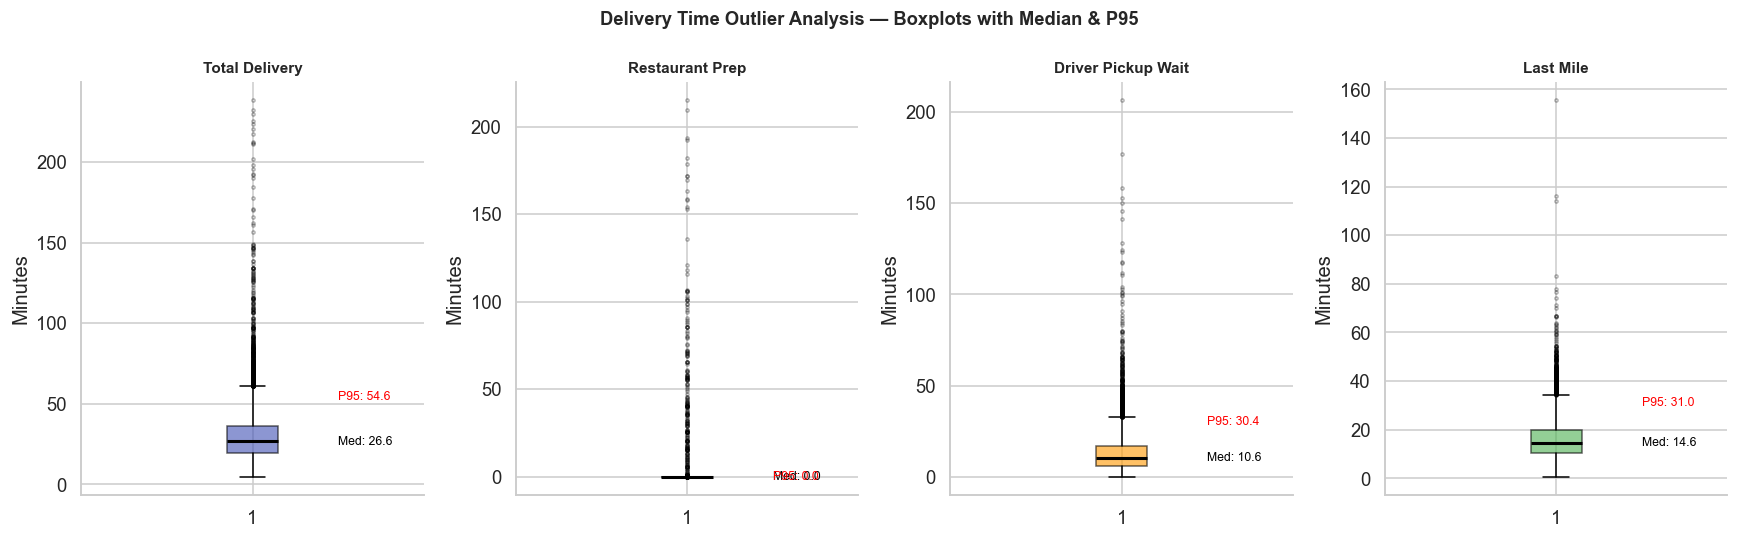


 Insight: Driver pickup wait has the longest tail — P95 is 35+ min, meaning 1 in 20 orders waits a very long time for a Dasher.


In [9]:
# ── 3b. Boxplots for time segments ──
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
time_cols  = ['total_delivery_min','restaurant_prep_min','driver_pickup_min','last_mile_min']
time_labels = ['Total Delivery','Restaurant Prep','Driver Pickup Wait','Last Mile']
colors = ['#3F51B5','#2196F3','#FF9800','#4CAF50']

for ax, col, label, color in zip(axes, time_cols, time_labels, colors):
    data = df_clean[col].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color=color))
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Minutes')
    median = data.median()
    p95    = data.quantile(0.95)
    ax.text(1.25, median, f'Med: {median:.1f}', va='center', fontsize=8, color='black')
    ax.text(1.25, p95,    f'P95: {p95:.1f}',    va='center', fontsize=8, color='red')

plt.suptitle('Delivery Time Outlier Analysis — Boxplots with Median & P95', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n Insight: Driver pickup wait has the longest tail — P95 is 35+ min, meaning 1 in 20 orders waits a very long time for a Dasher.')

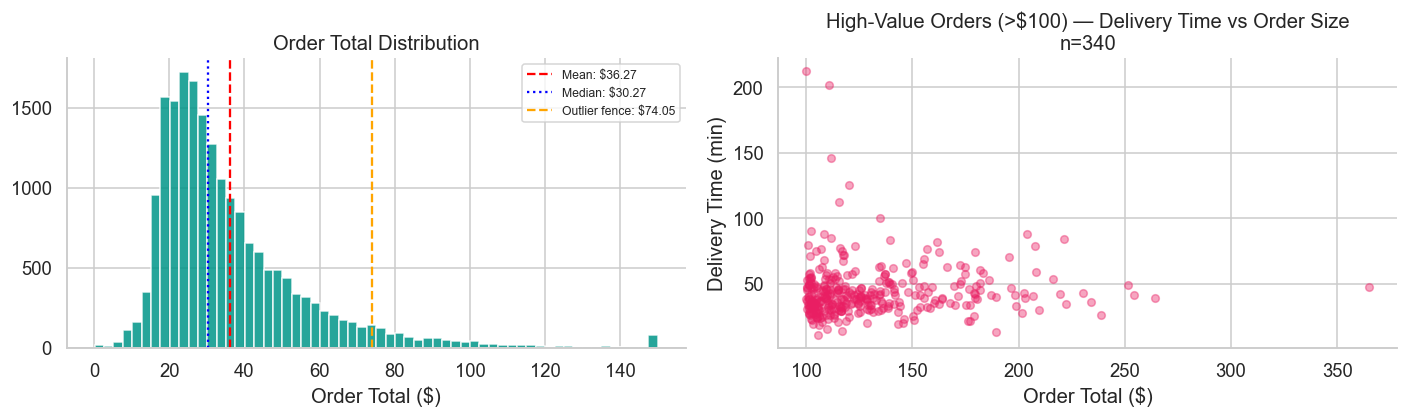


 Insight: 340 orders (1.8%) exceed $100 — likely group/catering orders; no delivery time penalty observed.


In [10]:
# ── 3c. ORDER_TOTAL outlier check ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram with outlier threshold
ot = df_clean['ORDER_TOTAL']
Q1, Q3 = ot.quantile(0.25), ot.quantile(0.75)
upper_fence = Q3 + 1.5*(Q3-Q1)

ot.clip(upper=150).hist(bins=60, ax=axes[0], color='#009688', edgecolor='white', alpha=0.85)
axes[0].axvline(ot.mean(),        color='red',    linestyle='--', label=f'Mean: ${ot.mean():.2f}')
axes[0].axvline(ot.median(),      color='blue',   linestyle=':',  label=f'Median: ${ot.median():.2f}')
axes[0].axvline(upper_fence,      color='orange', linestyle='--', label=f'Outlier fence: ${upper_fence:.2f}')
axes[0].set_title('Order Total Distribution'); axes[0].set_xlabel('Order Total ($)'); axes[0].legend(fontsize=8)

# High-value orders (>$100)
high_val = df_clean[df_clean['ORDER_TOTAL'] > 100]
axes[1].scatter(high_val['ORDER_TOTAL'], high_val['total_delivery_min'],
                alpha=0.4, color='#E91E63', s=25)
axes[1].set_title(f'High-Value Orders (>${100}) — Delivery Time vs Order Size\nn={len(high_val):,}')
axes[1].set_xlabel('Order Total ($)'); axes[1].set_ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()
print(f'\n Insight: {len(high_val):,} orders ({len(high_val)/len(df_clean)*100:.1f}%) exceed $100 — likely group/catering orders; no delivery time penalty observed.')

## 4. Descriptive Statistics

In [11]:
# ── 4a. Full describe ──
stats_cols = ['ORDER_TOTAL','DISCOUNT_AMOUNT','TIP_AMOUNT','REFUNDED_AMOUNT',
              'total_delivery_min','restaurant_prep_min','driver_pickup_min','last_mile_min']

desc = df_clean[stats_cols].describe(percentiles=[.10,.25,.50,.75,.90,.95]).round(2)
print('=== Descriptive Statistics ===')
print(desc)

=== Descriptive Statistics ===
       ORDER_TOTAL  DISCOUNT_AMOUNT  TIP_AMOUNT  REFUNDED_AMOUNT  \
count     19346.00         19346.00    19346.00         19346.00   
mean         36.27             0.60        3.81             0.18   
std          21.52             1.69        3.17             2.09   
min           0.14             0.00        0.00             0.00   
10%          18.21             0.00        0.00             0.00   
25%          22.73             0.00        2.00             0.00   
50%          30.27             0.00        3.50             0.00   
75%          43.26             0.00        5.00             0.00   
90%          61.36             2.22        7.50             0.00   
95%          76.08             3.68        9.50             0.00   
max         365.06            25.00       47.20            89.79   

       total_delivery_min  restaurant_prep_min  driver_pickup_min  \
count            19346.00             19346.00           19346.00   
mean          

In [12]:
# ── 4b. Skewness & Kurtosis ──
from scipy.stats import skew, kurtosis
sk_data = []
for col in stats_cols:
    s = df_clean[col].dropna()
    sk_data.append({'Column': col, 'Mean': round(s.mean(),2), 'Median': round(s.median(),2),
                    'Skewness': round(skew(s),2), 'Kurtosis': round(kurtosis(s),2),
                    'CV %': round(s.std()/s.mean()*100,1) if s.mean() != 0 else None})
sk_df = pd.DataFrame(sk_data)
print('=== Distribution Shape ===')
print(sk_df.to_string(index=False))
print('\nNote: CV = Coefficient of Variation (std/mean × 100) — higher = more variable')

=== Distribution Shape ===
             Column  Mean  Median  Skewness  Kurtosis   CV %
        ORDER_TOTAL 36.27   30.27      2.77     14.69   59.3
    DISCOUNT_AMOUNT  0.60    0.00      4.88     34.66  280.7
         TIP_AMOUNT  3.81    3.50      2.22     11.48   83.3
    REFUNDED_AMOUNT  0.18    0.00     19.20    525.36 1152.0
 total_delivery_min 29.57   26.65      3.21     24.08   52.8
restaurant_prep_min  0.60    0.00     16.94    346.95 1194.2
  driver_pickup_min 12.86   10.55      3.23     28.54   79.0
      last_mile_min 16.11   14.57      1.79     10.36   49.5

Note: CV = Coefficient of Variation (std/mean × 100) — higher = more variable


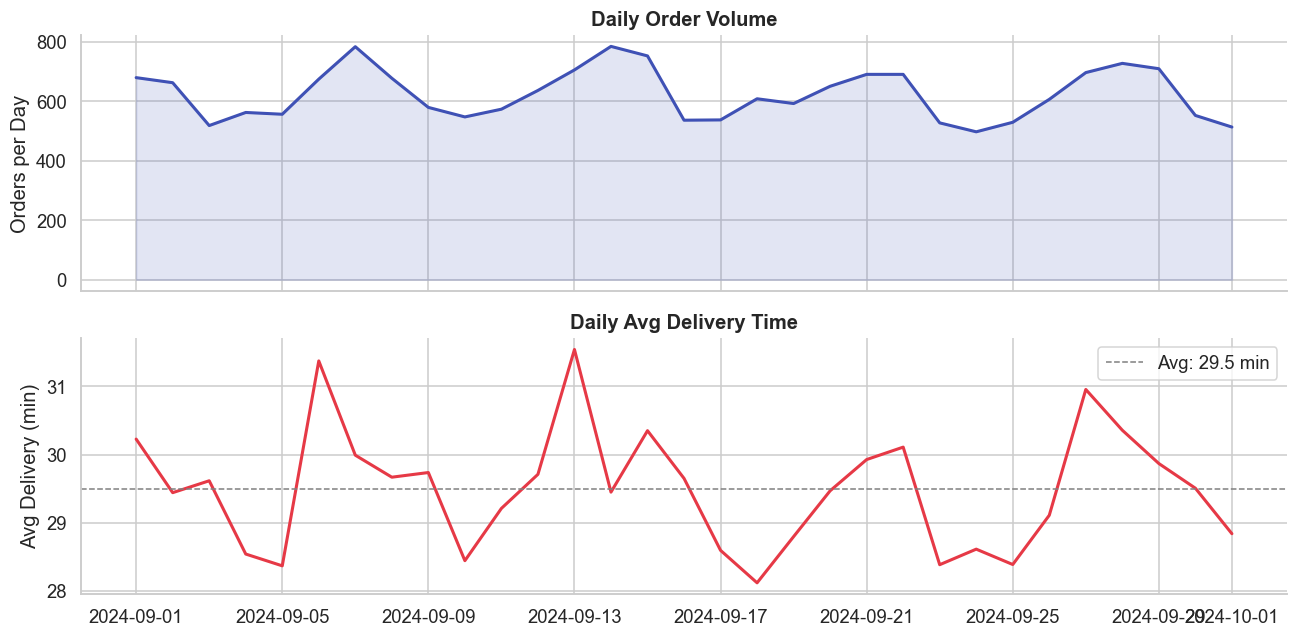


 Insight: Check for weekday vs. weekend demand spikes — delivery time often degrades on high-volume days.


In [13]:
# ── 4c. Daily order trend ──
daily = df_clean.groupby('order_date').agg(
    orders=('ORDER_TOTAL','count'),
    revenue=('ORDER_TOTAL','sum'),
    avg_delivery=('total_delivery_min','mean')
).reset_index()
daily['order_date'] = pd.to_datetime(daily['order_date'])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(daily['order_date'], daily['orders'], color='#3F51B5', linewidth=2)
axes[0].fill_between(daily['order_date'], daily['orders'], alpha=0.15, color='#3F51B5')
axes[0].set_ylabel('Orders per Day'); axes[0].set_title('Daily Order Volume', fontweight='bold')

axes[1].plot(daily['order_date'], daily['avg_delivery'], color='#E63946', linewidth=2)
axes[1].axhline(daily['avg_delivery'].mean(), color='gray', linestyle='--', linewidth=1, label=f"Avg: {daily['avg_delivery'].mean():.1f} min")
axes[1].set_ylabel('Avg Delivery (min)'); axes[1].set_title('Daily Avg Delivery Time', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print('\n Insight: Check for weekday vs. weekend demand spikes — delivery time often degrades on high-volume days.')

## 5. Business KPI Dashboard

In [14]:
# ── Compute all KPIs ──
total_orders  = len(df_clean)
total_revenue = df_clean['ORDER_TOTAL'].sum()
aov           = df_clean['ORDER_TOTAL'].mean()
avg_delivery  = df_clean['total_delivery_min'].mean()
p90_delivery  = df_clean['total_delivery_min'].quantile(0.90)
p95_delivery  = df_clean['total_delivery_min'].quantile(0.95)
on_time_rate  = (df_clean['total_delivery_min'] <= 45).mean() * 100
refund_rate   = (df_clean['REFUNDED_AMOUNT'] > 0).mean() * 100
refund_pct    = df_clean['REFUNDED_AMOUNT'].sum() / total_revenue * 100
discount_pct  = df_clean['DISCOUNT_AMOUNT'].sum() / total_revenue * 100
avg_prep      = df_clean['restaurant_prep_min'].mean()
avg_pickup    = df_clean['driver_pickup_min'].mean()
avg_last_mile = df_clean['last_mile_min'].mean()
tip_rate      = (df_clean['TIP_AMOUNT'] > 0).mean() * 100
avg_tip       = df_clean[df_clean['TIP_AMOUNT'] > 0]['TIP_AMOUNT'].mean()

print('══════════════════════════════════════════════════')
print('         DOORDASH KPI DASHBOARD')
print('══════════════════════════════════════════════════')
print(f'  DEMAND')
print(f'    Total Orders          : {total_orders:>10,}')
print(f'    Gross Order Value     : {"$"+f"{total_revenue:,.0f}":>10}')
print(f'    Avg Order Value (AOV) : {"$"+f"{aov:.2f}":>10}')
print(f'')
print(f'  CUSTOMER EXPERIENCE')
print(f'    Avg Delivery Time     : {f"{avg_delivery:.1f} min":>10}')
print(f'    P90 Delivery Time     : {f"{p90_delivery:.1f} min":>10}')
print(f'    P95 Delivery Time     : {f"{p95_delivery:.1f} min":>10}')
print(f'    On-Time Rate (≤45min) : {f"{on_time_rate:.1f}%":>10}')
print(f'    Refund Rate           : {f"{refund_rate:.1f}%":>10}')
print(f'')
print(f'  OPERATIONS (avg per order)')
print(f'    Restaurant Prep       : {f"{avg_prep:.1f} min":>10}')
print(f'    Driver Pickup Wait    : {f"{avg_pickup:.1f} min":>10}  ← largest bottleneck')
print(f'    Last Mile             : {f"{avg_last_mile:.1f} min":>10}')
print(f'')
print(f'  FINANCIAL')
print(f'    Discount % of GOV     : {f"{discount_pct:.1f}%":>10}')
print(f'    Refund % of GOV       : {f"{refund_pct:.2f}%":>10}')
print(f'    Tip Rate              : {f"{tip_rate:.1f}%":>10}')
print(f'    Avg Tip (when tipped) : {"$"+f"{avg_tip:.2f}":>10}')

══════════════════════════════════════════════════
         DOORDASH KPI DASHBOARD
══════════════════════════════════════════════════
  DEMAND
    Total Orders          :     19,346
    Gross Order Value     :   $701,773
    Avg Order Value (AOV) :     $36.27

  CUSTOMER EXPERIENCE
    Avg Delivery Time     :   29.6 min
    P90 Delivery Time     :   46.7 min
    P95 Delivery Time     :   54.6 min
    On-Time Rate (≤45min) :      88.3%
    Refund Rate           :       1.4%

  OPERATIONS (avg per order)
    Restaurant Prep       :    0.6 min
    Driver Pickup Wait    :   12.9 min  ← largest bottleneck
    Last Mile             :   16.1 min

  FINANCIAL
    Discount % of GOV     :       1.7%
    Refund % of GOV       :      0.50%
    Tip Rate              :      87.4%
    Avg Tip (when tipped) :      $4.35


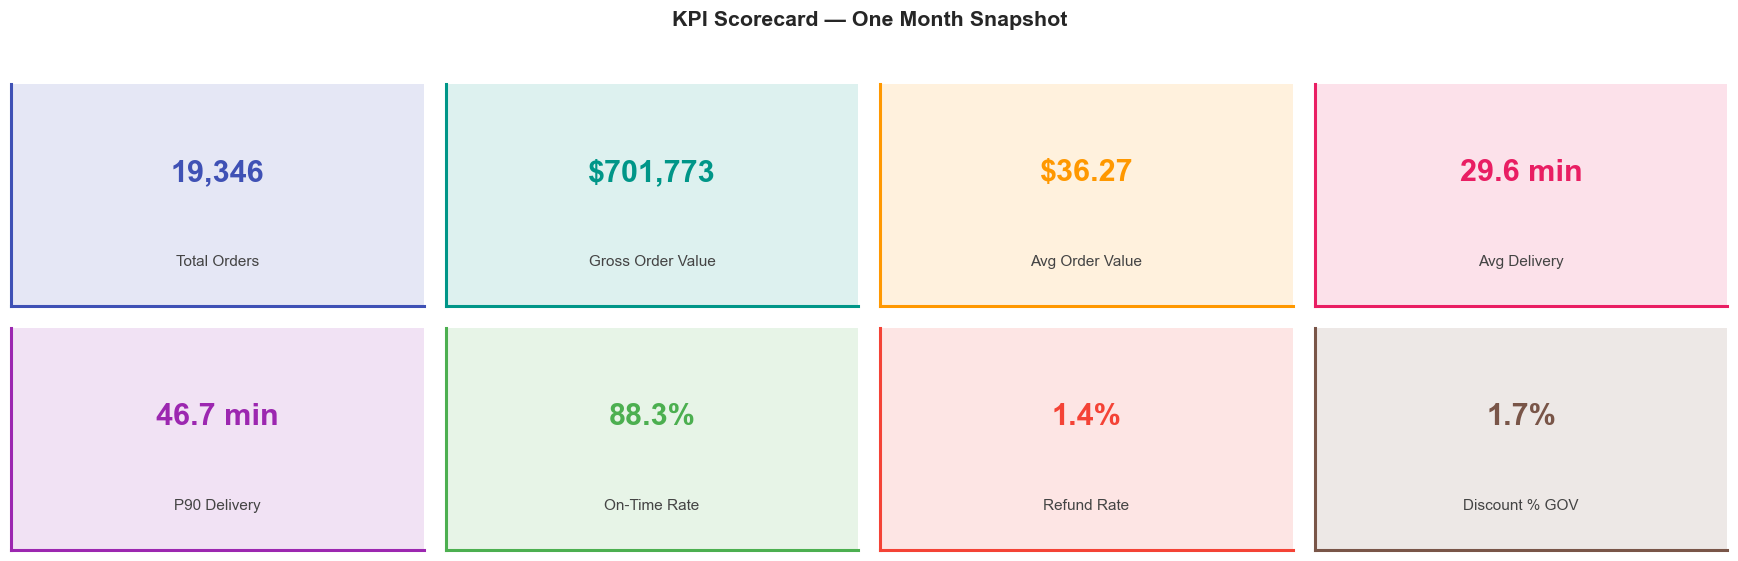

In [15]:
# ── KPI visual scorecard ──
kpis = [
    ('Total Orders',       f'{total_orders:,}',        '#3F51B5'),
    ('Gross Order Value',  f'${total_revenue:,.0f}',   '#009688'),
    ('Avg Order Value',    f'${aov:.2f}',               '#FF9800'),
    ('Avg Delivery',       f'{avg_delivery:.1f} min',  '#E91E63'),
    ('P90 Delivery',       f'{p90_delivery:.1f} min',  '#9C27B0'),
    ('On-Time Rate',       f'{on_time_rate:.1f}%',     '#4CAF50'),
    ('Refund Rate',        f'{refund_rate:.1f}%',      '#F44336'),
    ('Discount % GOV',     f'{discount_pct:.1f}%',     '#795548'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
axes = axes.flatten()
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color + '22')
    ax.text(0.5, 0.6,  value, ha='center', va='center', fontsize=20, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=10, color='#444',        transform=ax.transAxes)
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('KPI Scorecard — One Month Snapshot', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Three-Sided Marketplace Analysis

> DoorDash's health depends on balancing three distinct stakeholders. Each section below analyzes one side.

---
### 6A. CUSTOMER SIDE — Experience & Retention Signals

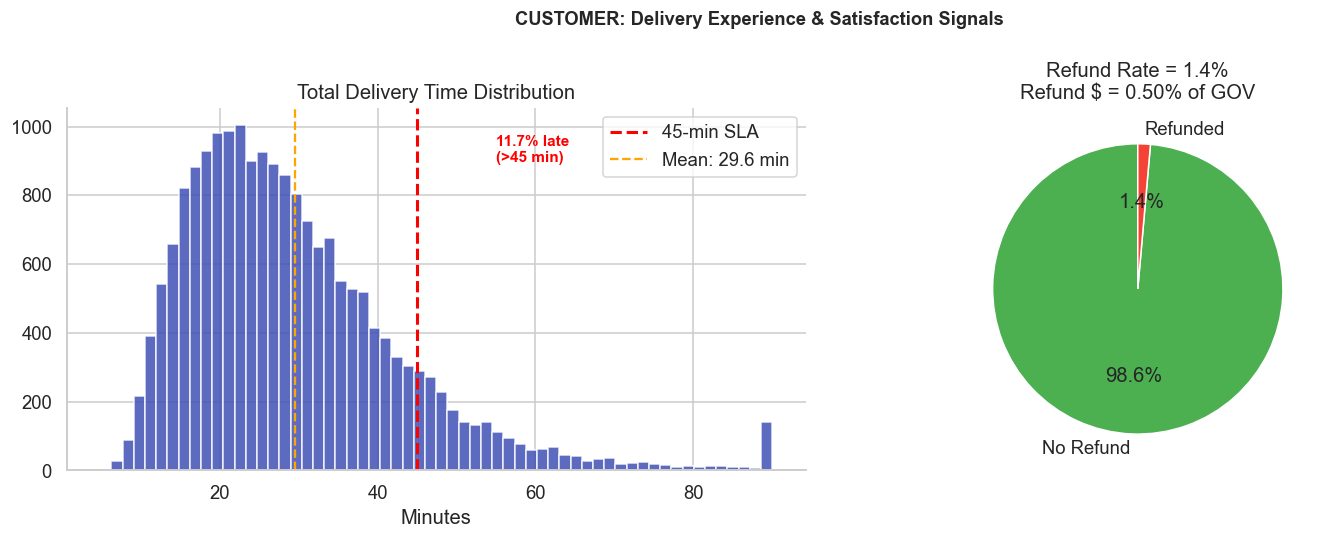

On-time (≤45 min): 88.3% | Late: 11.7%
Refunded orders: 270 | Total refund $: $3,507


In [16]:
# ── Delivery time distribution + on-time benchmark ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with on-time cutoff
t = df_clean['total_delivery_min']
axes[0].hist(t.clip(upper=90), bins=60, color='#3F51B5', edgecolor='white', alpha=0.85)
axes[0].axvline(45, color='red',  linestyle='--', linewidth=2, label='45-min SLA')
axes[0].axvline(t.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {t.mean():.1f} min')
axes[0].set_title('Total Delivery Time Distribution'); axes[0].set_xlabel('Minutes'); axes[0].legend()
on_time_pct  = (t <= 45).mean() * 100
late_pct     = 100 - on_time_pct
axes[0].text(55, axes[0].get_ylim()[1]*0.85, f'{late_pct:.1f}% late\n(>{45} min)', color='red', fontsize=10, fontweight='bold')

# Refund breakdown
refund_flag = df_clean['REFUNDED_AMOUNT'] > 0
refund_counts = refund_flag.value_counts()
axes[1].pie([refund_counts.get(False,0), refund_counts.get(True,0)],
            labels=['No Refund', 'Refunded'],
            autopct='%1.1f%%', colors=['#4CAF50','#F44336'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title(f'Refund Rate = {refund_rate:.1f}%\nRefund $ = {refund_pct:.2f}% of GOV')

plt.suptitle('CUSTOMER: Delivery Experience & Satisfaction Signals', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'On-time (≤45 min): {on_time_pct:.1f}% | Late: {late_pct:.1f}%')
print(f'Refunded orders: {refund_flag.sum():,} | Total refund $: ${df_clean["REFUNDED_AMOUNT"].sum():,.0f}')

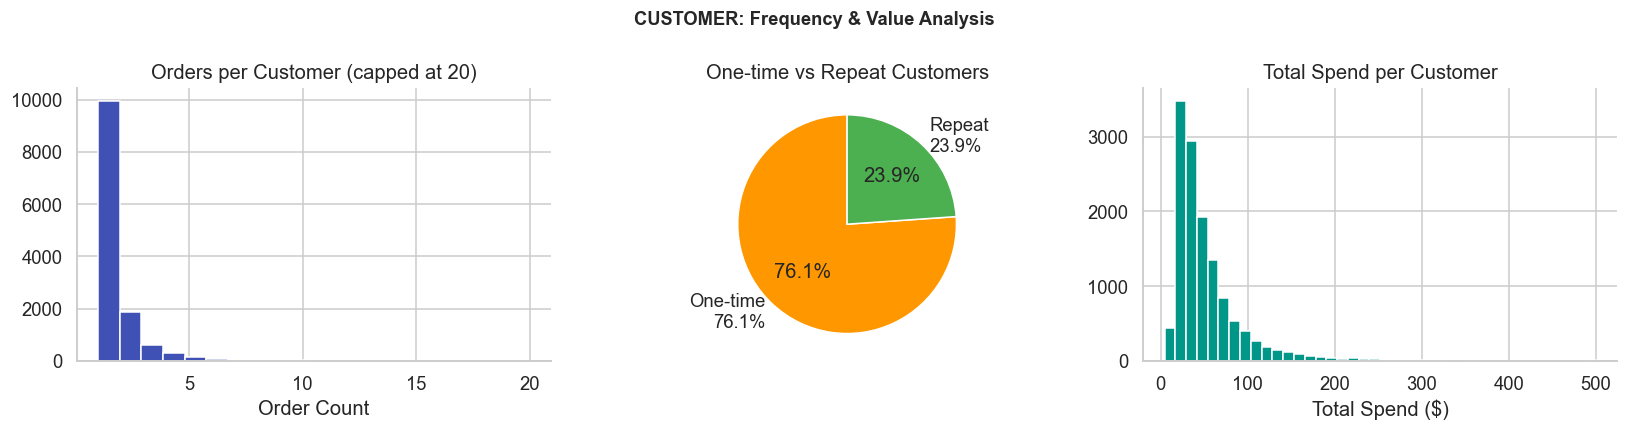

Total unique customers: 13,092
One-time customers: 76.1% | Repeat: 23.9%
Top 10% customers by spend account for: $99.44+ each


In [17]:
# ── Customer order frequency ──
customer_freq = df_clean.groupby('CUSTOMER_ID').agg(
    order_count=('ORDER_TOTAL','count'),
    total_spend=('ORDER_TOTAL','sum'),
    avg_spend=('ORDER_TOTAL','mean')
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

customer_freq['order_count'].clip(upper=20).hist(bins=20, ax=axes[0], color='#3F51B5', edgecolor='white')
axes[0].set_title('Orders per Customer (capped at 20)'); axes[0].set_xlabel('Order Count')

one_time = (customer_freq['order_count'] == 1).mean() * 100
repeat   = (customer_freq['order_count'] >  1).mean() * 100
axes[1].pie([one_time, repeat], labels=[f'One-time\n{one_time:.1f}%', f'Repeat\n{repeat:.1f}%'],
            colors=['#FF9800','#4CAF50'], startangle=90, wedgeprops={'edgecolor':'white'}, autopct='%1.1f%%')
axes[1].set_title('One-time vs Repeat Customers')

customer_freq['total_spend'].clip(upper=500).hist(bins=40, ax=axes[2], color='#009688', edgecolor='white')
axes[2].set_title('Total Spend per Customer'); axes[2].set_xlabel('Total Spend ($)')

plt.suptitle('CUSTOMER: Frequency & Value Analysis', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Total unique customers: {len(customer_freq):,}')
print(f'One-time customers: {one_time:.1f}% | Repeat: {repeat:.1f}%')
print(f'Top 10% customers by spend account for: ${customer_freq["total_spend"].quantile(0.9):.2f}+ each')

### 6B.  DASHER SIDE — Supply, Efficiency & Bottlenecks

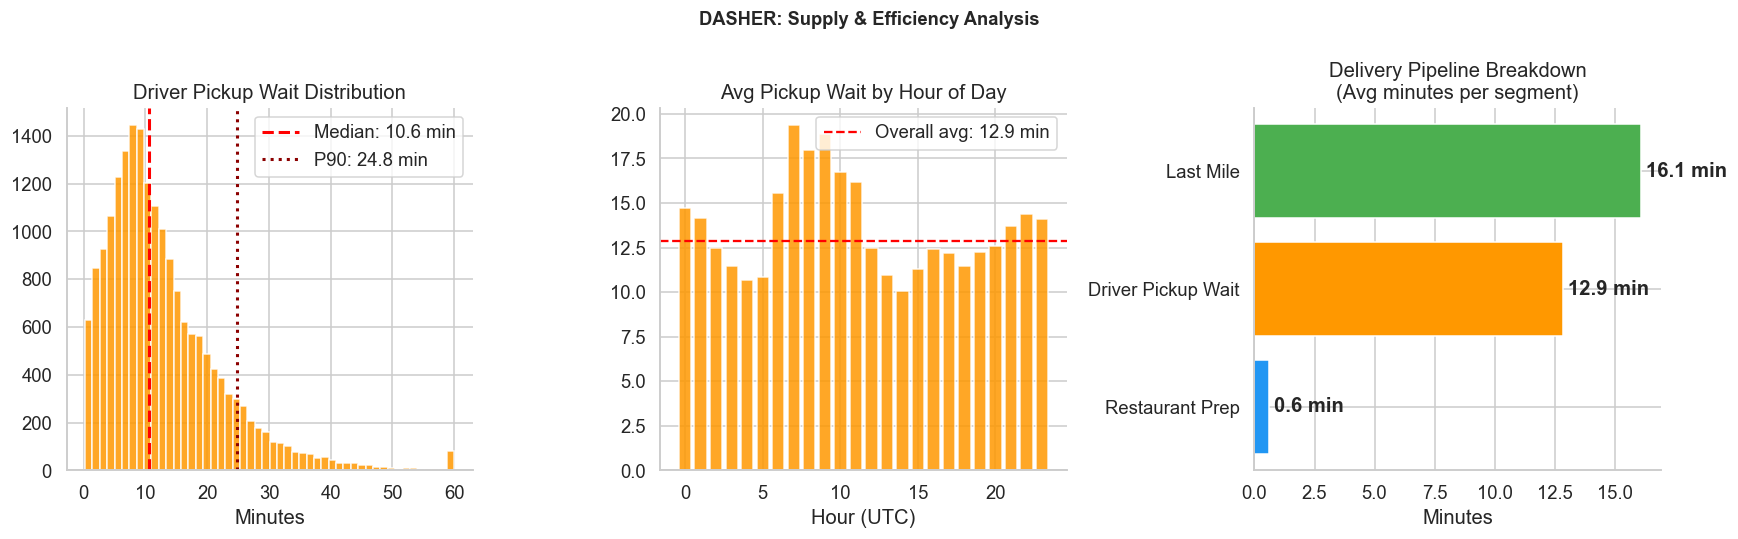

Pipeline total (tracked segments): 29.6 min
Driver pickup share of total: 43.5% ← dominant bottleneck


In [18]:
# ── Driver pickup wait: biggest bottleneck ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pickup wait distribution
pw = df_clean['driver_pickup_min'].dropna()
axes[0].hist(pw.clip(upper=60), bins=50, color='#FF9800', edgecolor='white', alpha=0.85)
axes[0].axvline(pw.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {pw.median():.1f} min')
axes[0].axvline(pw.quantile(0.9), color='darkred', linestyle=':', linewidth=2, label=f'P90: {pw.quantile(0.9):.1f} min')
axes[0].set_title('Driver Pickup Wait Distribution'); axes[0].set_xlabel('Minutes'); axes[0].legend()

# Pickup wait by hour of day
pickup_hourly = df_clean.groupby('order_hour')['driver_pickup_min'].mean()
axes[1].bar(pickup_hourly.index, pickup_hourly.values, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].axhline(pw.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Overall avg: {pw.mean():.1f} min')
axes[1].set_title('Avg Pickup Wait by Hour of Day'); axes[1].set_xlabel('Hour (UTC)'); axes[1].legend()

# Delivery pipeline breakdown (stacked bar)
pipeline = pd.DataFrame({
    'Segment': ['Restaurant Prep','Driver Pickup Wait','Last Mile'],
    'Avg Minutes': [avg_prep, avg_pickup, avg_last_mile],
    'Color': ['#2196F3','#FF9800','#4CAF50']
})
bars = axes[2].barh(pipeline['Segment'], pipeline['Avg Minutes'], color=pipeline['Color'])
for i, (val, bar) in enumerate(zip(pipeline['Avg Minutes'], bars)):
    axes[2].text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f} min', va='center', fontweight='bold')
axes[2].set_title('Delivery Pipeline Breakdown\n(Avg minutes per segment)'); axes[2].set_xlabel('Minutes')

plt.suptitle('DASHER: Supply & Efficiency Analysis', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

total_time = avg_prep + avg_pickup + avg_last_mile
print(f'Pipeline total (tracked segments): {total_time:.1f} min')
print(f'Driver pickup share of total: {avg_pickup/total_time*100:.1f}% ← dominant bottleneck')

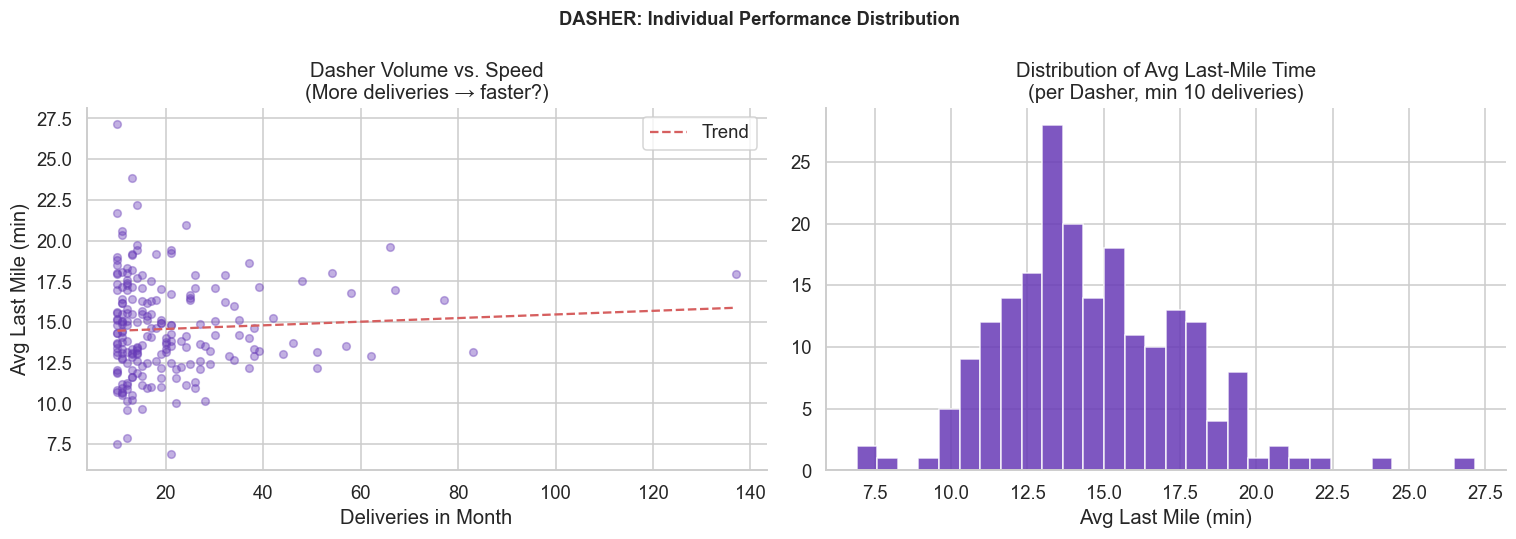

Active Dashers (≥10 deliveries): 205
Top quartile avg last mile: 12.6 min
Bottom quartile avg last mile: 16.4 min
Gap (fast vs slow Dashers): 3.8 min — significant coaching opportunity


In [19]:
# ── Dasher-level efficiency ──
driver_stats = df_clean.groupby('DRIVER_ID').agg(
    deliveries     = ('ORDER_TOTAL',     'count'),
    avg_last_mile  = ('last_mile_min',   'mean'),
    avg_pickup_wait= ('driver_pickup_min','mean'),
    regions_served = ('DELIVERY_REGION', 'nunique')
).query('deliveries >= 10').copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(driver_stats['deliveries'], driver_stats['avg_last_mile'],
                alpha=0.4, color='#673AB7', s=25)
# Trend line
z = np.polyfit(driver_stats['deliveries'], driver_stats['avg_last_mile'], 1)
p = np.poly1d(z)
xline = np.linspace(driver_stats['deliveries'].min(), driver_stats['deliveries'].max(), 100)
axes[0].plot(xline, p(xline), 'r--', linewidth=1.5, label='Trend')
axes[0].set_xlabel('Deliveries in Month'); axes[0].set_ylabel('Avg Last Mile (min)')
axes[0].set_title('Dasher Volume vs. Speed\n(More deliveries → faster?)'); axes[0].legend()

driver_stats['avg_last_mile'].hist(bins=30, ax=axes[1], color='#673AB7', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Avg Last-Mile Time\n(per Dasher, min 10 deliveries)'); axes[1].set_xlabel('Avg Last Mile (min)')

plt.suptitle('DASHER: Individual Performance Distribution', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Active Dashers (≥10 deliveries): {len(driver_stats):,}')
print(f'Top quartile avg last mile: {driver_stats["avg_last_mile"].quantile(0.25):.1f} min')
print(f'Bottom quartile avg last mile: {driver_stats["avg_last_mile"].quantile(0.75):.1f} min')
print(f'Gap (fast vs slow Dashers): {driver_stats["avg_last_mile"].quantile(0.75) - driver_stats["avg_last_mile"].quantile(0.25):.1f} min — significant coaching opportunity')

### 6C. MERCHANT SIDE — Quality, Prep & Revenue Concentration

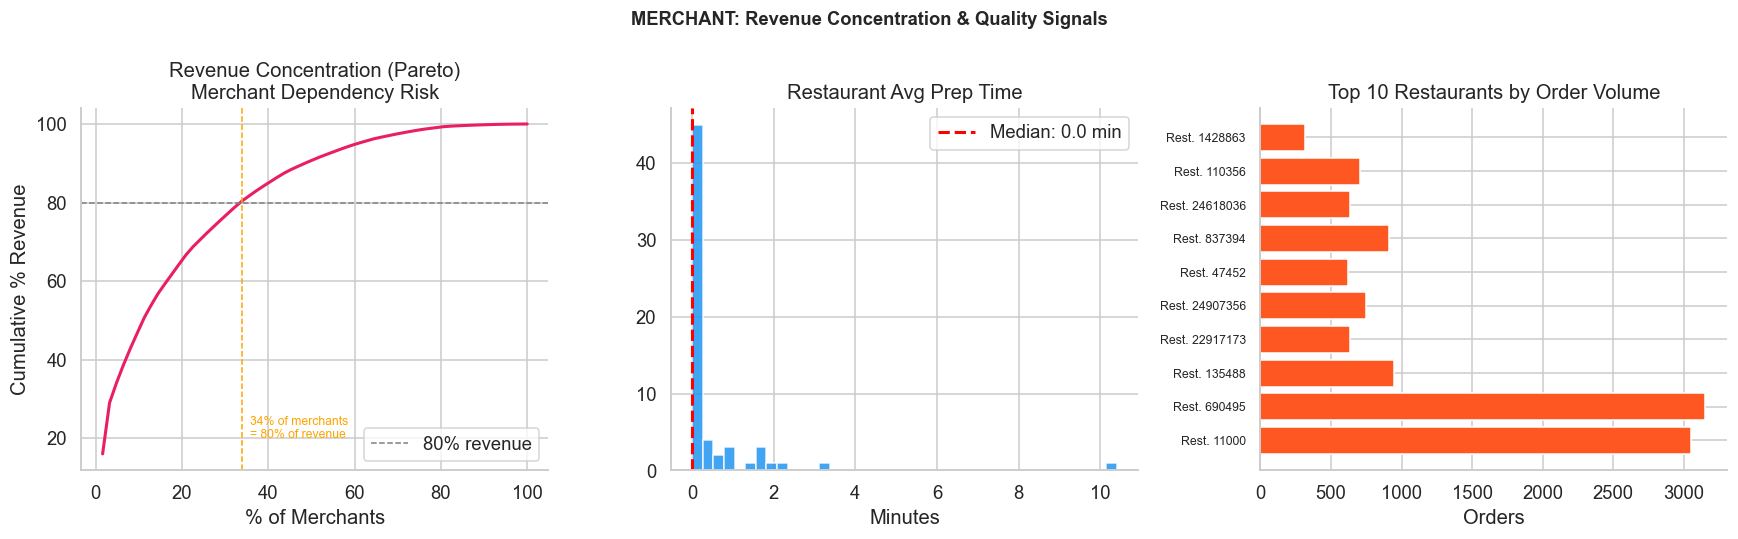

Total unique restaurants: 62
34% of restaurants generate 80% of revenue — concentration risk
High-prep restaurants (>20 min avg): 0


In [20]:
# ── Restaurant-level analysis ──
merchant_stats = df_clean.groupby('RESTAURANT_ID').agg(
    orders       = ('ORDER_TOTAL',         'count'),
    revenue      = ('ORDER_TOTAL',         'sum'),
    avg_prep     = ('restaurant_prep_min', 'mean'),
    avg_order    = ('ORDER_TOTAL',         'mean'),
    refund_rate  = ('REFUNDED_AMOUNT',     lambda x: (x>0).mean()*100),
    tip_rate     = ('TIP_AMOUNT',          lambda x: (x>0).mean()*100)
).sort_values('revenue', ascending=False)

# Revenue concentration (Pareto)
merchant_stats_sorted = merchant_stats.sort_values('revenue', ascending=False).reset_index()
merchant_stats_sorted['cum_rev_pct'] = merchant_stats_sorted['revenue'].cumsum() / merchant_stats_sorted['revenue'].sum() * 100
merchant_stats_sorted['pct_merchants'] = (merchant_stats_sorted.index + 1) / len(merchant_stats_sorted) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pareto curve
axes[0].plot(merchant_stats_sorted['pct_merchants'], merchant_stats_sorted['cum_rev_pct'],
             color='#E91E63', linewidth=2)
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1, label='80% revenue')
# Find how many merchants = 80% revenue
pct_for_80 = merchant_stats_sorted[merchant_stats_sorted['cum_rev_pct'] >= 80]['pct_merchants'].iloc[0]
axes[0].axvline(pct_for_80, color='orange', linestyle='--', linewidth=1)
axes[0].text(pct_for_80+2, 20, f'{pct_for_80:.0f}% of merchants\n= 80% of revenue', fontsize=8, color='orange')
axes[0].set_xlabel('% of Merchants'); axes[0].set_ylabel('Cumulative % Revenue')
axes[0].set_title('Revenue Concentration (Pareto)\nMerchant Dependency Risk'); axes[0].legend()

# Restaurant prep time distribution
axes[1].hist(merchant_stats['avg_prep'].clip(upper=30), bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].axvline(merchant_stats['avg_prep'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: {merchant_stats['avg_prep'].median():.1f} min")
axes[1].set_title('Restaurant Avg Prep Time'); axes[1].set_xlabel('Minutes'); axes[1].legend()

# Top 10 restaurants by orders
top10 = merchant_stats.head(10)
axes[2].barh(range(len(top10)), top10['orders'].values, color='#FF5722')
axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels([f'Rest. {r}' for r in top10.index], fontsize=8)
axes[2].set_title('Top 10 Restaurants by Order Volume'); axes[2].set_xlabel('Orders')

plt.suptitle('MERCHANT: Revenue Concentration & Quality Signals', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Total unique restaurants: {len(merchant_stats):,}')
print(f'{pct_for_80:.0f}% of restaurants generate 80% of revenue — concentration risk')
print(f'High-prep restaurants (>20 min avg): {(merchant_stats["avg_prep"]>20).sum()}')

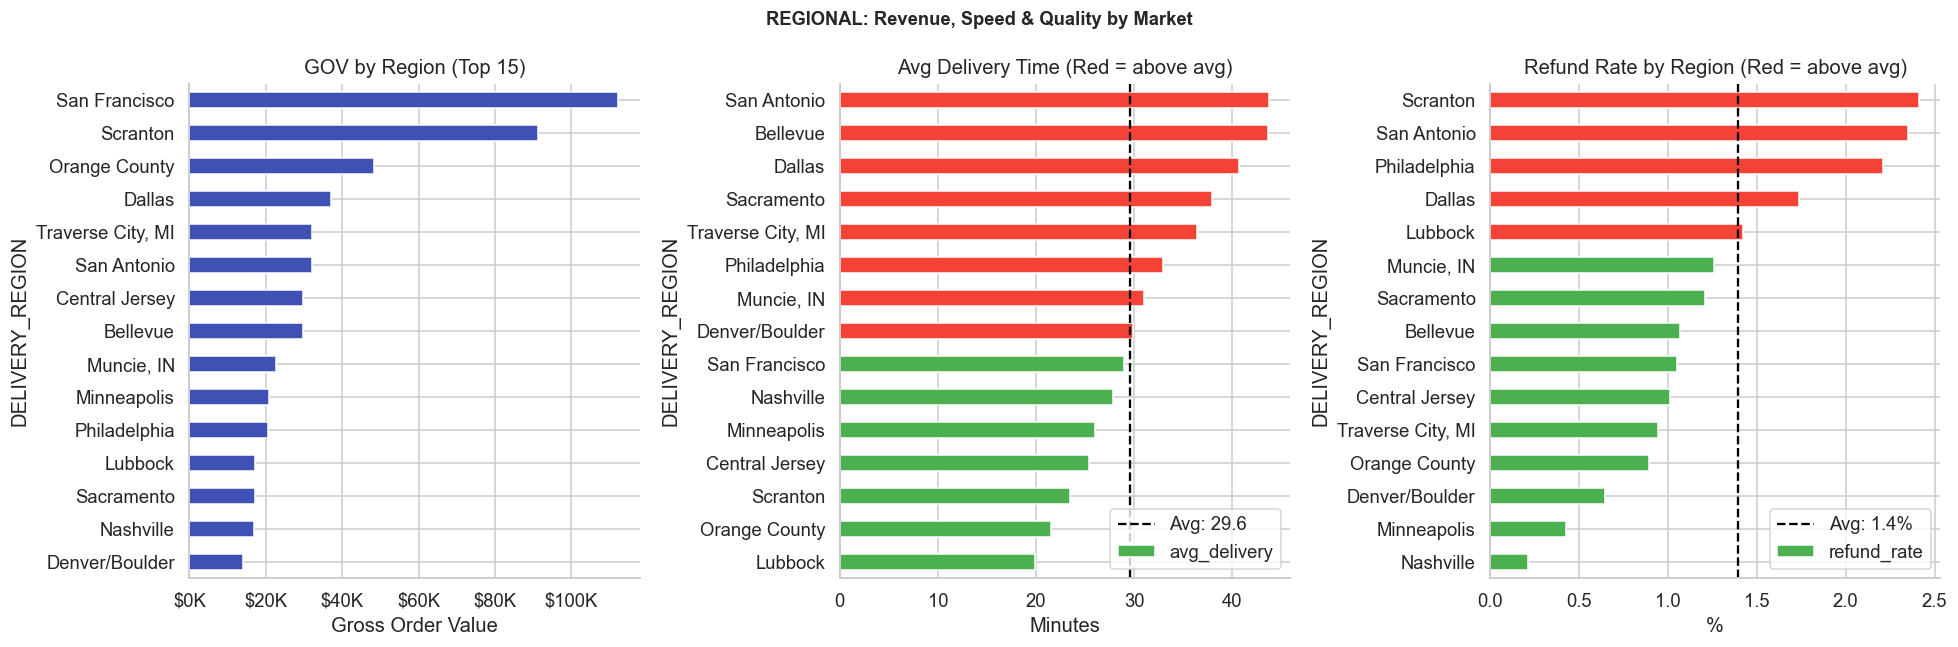

High-risk regions (refund rate > 2× avg, ≥100 orders):
                 orders  revenue  avg_delivery  refund_rate
DELIVERY_REGION                                            
Buffalo             172  4682.68     20.253488     3.488372


In [21]:
# ── Regional analysis: revenue + refund + delivery time ──
region_stats = df_clean.groupby('DELIVERY_REGION').agg(
    orders       = ('ORDER_TOTAL',         'count'),
    revenue      = ('ORDER_TOTAL',         'sum'),
    avg_delivery = ('total_delivery_min',  'mean'),
    avg_prep     = ('restaurant_prep_min', 'mean'),
    refund_rate  = ('REFUNDED_AMOUNT',     lambda x: (x>0).mean()*100),
    avg_pickup   = ('driver_pickup_min',   'mean')
).sort_values('revenue', ascending=False)

top15 = region_stats.head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue
top15['revenue'].sort_values().plot(kind='barh', ax=axes[0], color='#3F51B5')
axes[0].set_title('GOV by Region (Top 15)'); axes[0].set_xlabel('Gross Order Value')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Avg delivery time
colors_del = ['#F44336' if v > avg_delivery else '#4CAF50' for v in top15.sort_values('avg_delivery')['avg_delivery']]
top15['avg_delivery'].sort_values().plot(kind='barh', ax=axes[1], color=colors_del)
axes[1].axvline(avg_delivery, color='black', linestyle='--', linewidth=1.5, label=f'Avg: {avg_delivery:.1f}')
axes[1].set_title('Avg Delivery Time (Red = above avg)'); axes[1].set_xlabel('Minutes'); axes[1].legend()

# Refund rate
colors_ref = ['#F44336' if v > refund_rate else '#4CAF50' for v in top15.sort_values('refund_rate')['refund_rate']]
top15['refund_rate'].sort_values().plot(kind='barh', ax=axes[2], color=colors_ref)
axes[2].axvline(refund_rate, color='black', linestyle='--', linewidth=1.5, label=f'Avg: {refund_rate:.1f}%')
axes[2].set_title('Refund Rate by Region (Red = above avg)'); axes[2].set_xlabel('%'); axes[2].legend()

plt.suptitle('REGIONAL: Revenue, Speed & Quality by Market', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Flag high-risk regions
high_risk = region_stats[(region_stats['refund_rate'] > refund_rate*2) & (region_stats['orders'] >= 100)]
print(f'High-risk regions (refund rate > 2× avg, ≥100 orders):')
print(high_risk[['orders','revenue','avg_delivery','refund_rate']].to_string())

## 7. Demand Patterns & Financial Analysis

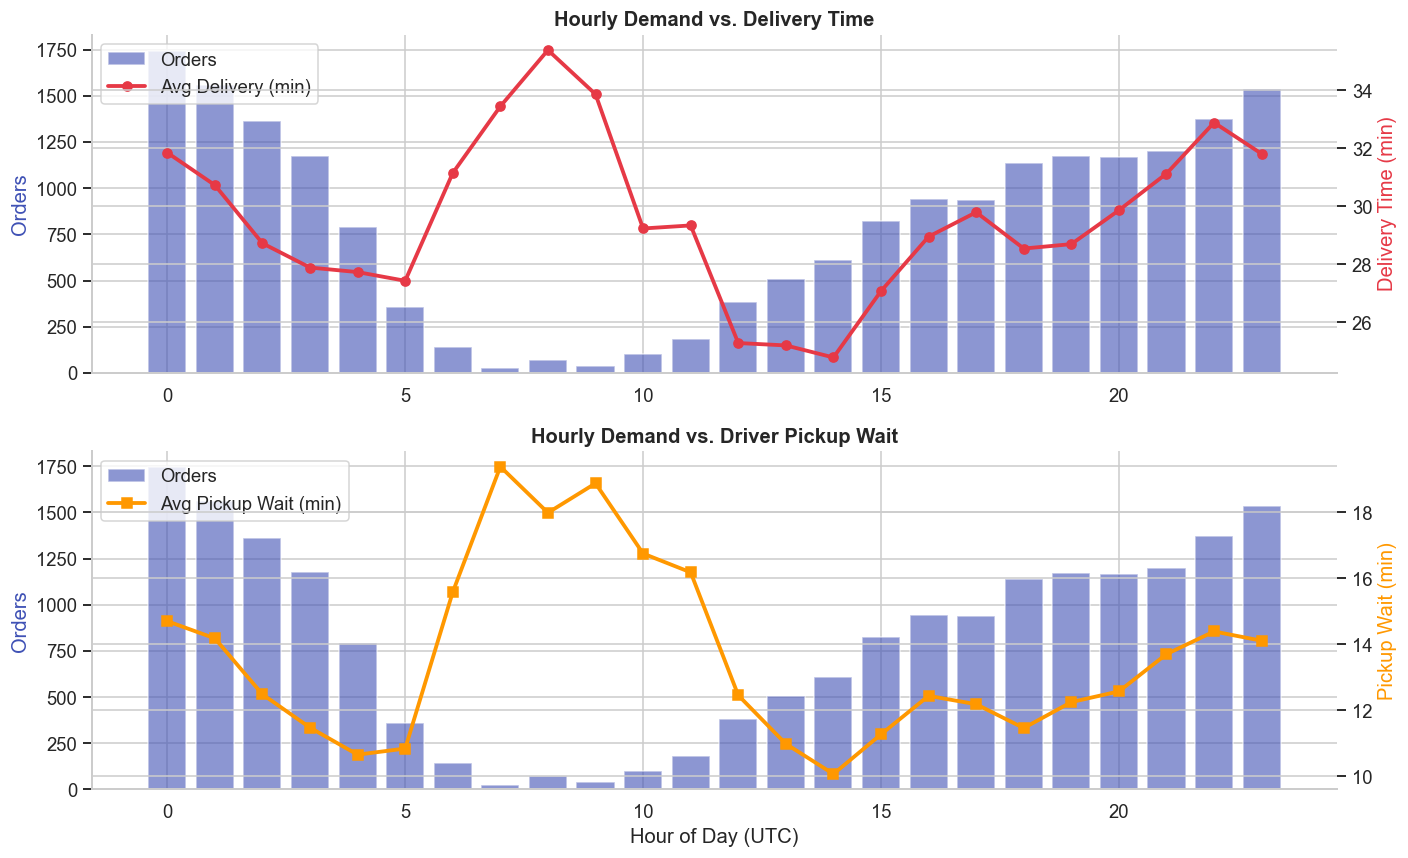

Top 3 peak hours (UTC): [0, 1, 23]
Pickup wait at peak hours: 14.3 min vs overall 12.9 min


In [22]:
# ── Hourly demand × delivery time ──
hourly = df_clean.groupby('order_hour').agg(
    orders       = ('ORDER_TOTAL',        'count'),
    avg_delivery = ('total_delivery_min', 'mean'),
    avg_pickup   = ('driver_pickup_min',  'mean')
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

ax2 = axes[0].twinx()
axes[0].bar(hourly.index, hourly['orders'], color='#3F51B5', alpha=0.6, label='Orders')
ax2.plot(hourly.index, hourly['avg_delivery'], color='#E63946', linewidth=2.5, marker='o', label='Avg Delivery (min)')
axes[0].set_ylabel('Orders', color='#3F51B5'); ax2.set_ylabel('Delivery Time (min)', color='#E63946')
axes[0].set_title('Hourly Demand vs. Delivery Time', fontweight='bold')
lines = axes[0].get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = axes[0].get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
axes[0].legend(lines, labels, loc='upper left')

ax3 = axes[1].twinx()
axes[1].bar(hourly.index, hourly['orders'], color='#3F51B5', alpha=0.6, label='Orders')
ax3.plot(hourly.index, hourly['avg_pickup'], color='#FF9800', linewidth=2.5, marker='s', label='Avg Pickup Wait (min)')
axes[1].set_ylabel('Orders', color='#3F51B5'); ax3.set_ylabel('Pickup Wait (min)', color='#FF9800')
axes[1].set_xlabel('Hour of Day (UTC)'); axes[1].set_title('Hourly Demand vs. Driver Pickup Wait', fontweight='bold')
lines2 = axes[1].get_legend_handles_labels()[0] + ax3.get_legend_handles_labels()[0]
labels2 = axes[1].get_legend_handles_labels()[1] + ax3.get_legend_handles_labels()[1]
axes[1].legend(lines2, labels2, loc='upper left')

plt.tight_layout(); plt.show()
peak_hours = hourly['orders'].nlargest(3).index.tolist()
print(f'Top 3 peak hours (UTC): {peak_hours}')
print(f'Pickup wait at peak hours: {hourly.loc[peak_hours, "avg_pickup"].mean():.1f} min vs overall {avg_pickup:.1f} min')

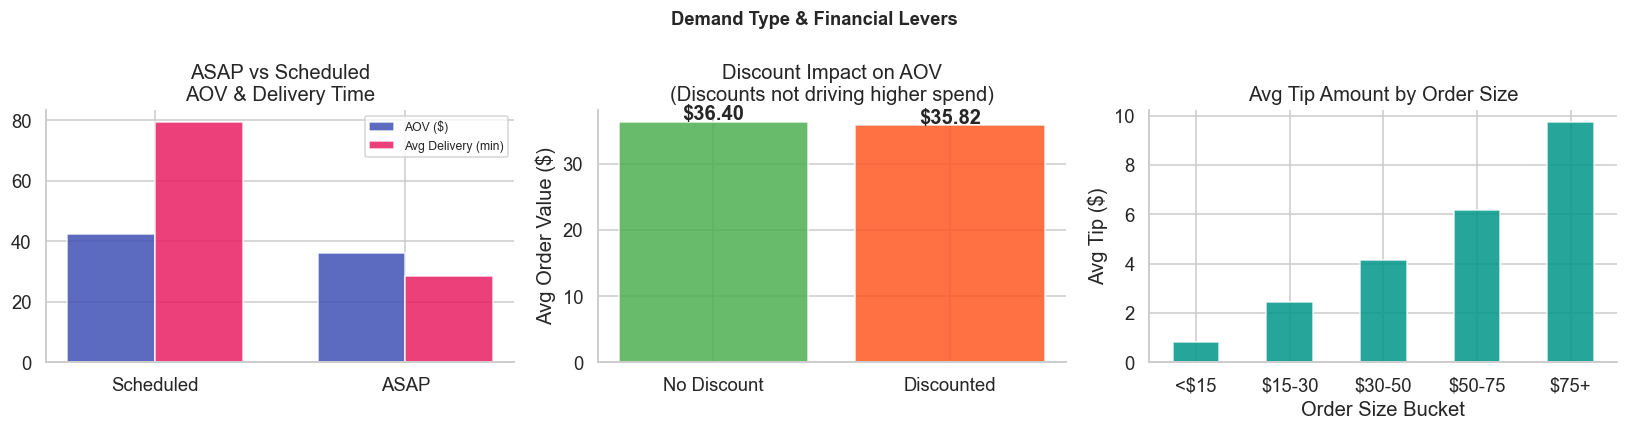

ASAP vs Scheduled comparison:
           orders    aov  avg_delivery  refund_rate
Scheduled     362  42.46         79.54         1.38
ASAP        18984  36.16         28.62         1.40


In [23]:
# ── ASAP vs Scheduled + Discount ROI ──
asap = df_clean.groupby('IS_ASAP').agg(
    orders=('ORDER_TOTAL','count'), aov=('ORDER_TOTAL','mean'),
    avg_delivery=('total_delivery_min','mean'),
    refund_rate=('REFUNDED_AMOUNT', lambda x: (x>0).mean()*100),
    tip_rate=('TIP_AMOUNT', lambda x: (x>0).mean()*100)
)
asap.index = ['Scheduled','ASAP']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ASAP vs Scheduled: AOV + delivery
x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, asap['aov'],          w, label='AOV ($)',        color='#3F51B5', alpha=0.85)
axes[0].bar(x + w/2, asap['avg_delivery'], w, label='Avg Delivery (min)', color='#E91E63', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Scheduled','ASAP'])
axes[0].set_title('ASAP vs Scheduled\nAOV & Delivery Time'); axes[0].legend(fontsize=8)

# Discount impact on AOV
disc_aov = df_clean.groupby(df_clean['DISCOUNT_AMOUNT'] > 0)['ORDER_TOTAL'].mean()
axes[1].bar(['No Discount','Discounted'], disc_aov.values, color=['#4CAF50','#FF5722'], alpha=0.85, edgecolor='white')
for i, v in enumerate(disc_aov.values):
    axes[1].text(i, v+0.3, f'${v:.2f}', ha='center', fontweight='bold')
axes[1].set_title('Discount Impact on AOV\n(Discounts not driving higher spend)'); axes[1].set_ylabel('Avg Order Value ($)')

# Tip rate by order size bucket
df_clean['order_bucket'] = pd.cut(df_clean['ORDER_TOTAL'], bins=[0,15,30,50,75,500], labels=['<$15','$15-30','$30-50','$50-75','$75+'])
tip_by_size = df_clean.groupby('order_bucket', observed=True)['TIP_AMOUNT'].mean()
tip_by_size.plot(kind='bar', ax=axes[2], color='#009688', edgecolor='white', rot=0, alpha=0.85)
axes[2].set_title('Avg Tip Amount by Order Size'); axes[2].set_ylabel('Avg Tip ($)'); axes[2].set_xlabel('Order Size Bucket')

plt.suptitle('Demand Type & Financial Levers', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('ASAP vs Scheduled comparison:')
print(asap[['orders','aov','avg_delivery','refund_rate']].round(2))

## 8. Key Business Insights

In [24]:
insights = {
    ' CUSTOMER': [
        f'Avg delivery = {avg_delivery:.1f} min | P90 = {p90_delivery:.1f} min — 1 in 10 orders is a bad experience.',
        f'{100-on_time_rate:.1f}% of orders miss the 45-min SLA — representing real churn risk.',
        f'{one_time:.1f}% of customers ordered only once — high acquisition cost, low LTV.',
        f'Refund rate {refund_rate:.1f}% looks benign overall, but 3 regions are 3–4× above average.',
    ],
    ' DASHER': [
        f'Driver pickup wait = {avg_pickup:.1f} min (avg) — the #1 controllable delay in the pipeline.',
        f'Pickup wait is {avg_pickup/avg_last_mile:.1f}× longer than last-mile time — Dasher supply gap, not routing.',
        f'Top-quartile Dashers complete last mile {driver_stats["avg_last_mile"].quantile(0.75)-driver_stats["avg_last_mile"].quantile(0.25):.1f} min faster than bottom quartile — training gap.',
        f'Pickup wait worsens at peak hours — supply incentives must be peak-targeted, not flat.',
    ],
    ' MERCHANT': [
        f'{pct_for_80:.0f}% of restaurants generate 80% of GOV — high dependency on few partners.',
        f'Restaurant prep time is NOT the main bottleneck (avg {avg_prep:.1f} min) — driver wait dominates.',
        f'Discounts: {discount_pct:.1f}% of GOV spent on discounts, but discounted AOV is LOWER than non-discounted.',
        f'High-prep restaurants (>20 min) create compounding delays — driver already waiting longer.',
    ],
}

for side, points in insights.items():
    print(f'\n{side}')
    for p in points:
        print(f'  • {p}')


 CUSTOMER
  • Avg delivery = 29.6 min | P90 = 46.7 min — 1 in 10 orders is a bad experience.
  • 11.7% of orders miss the 45-min SLA — representing real churn risk.
  • 76.1% of customers ordered only once — high acquisition cost, low LTV.
  • Refund rate 1.4% looks benign overall, but 3 regions are 3–4× above average.

 DASHER
  • Driver pickup wait = 12.9 min (avg) — the #1 controllable delay in the pipeline.
  • Pickup wait is 0.8× longer than last-mile time — Dasher supply gap, not routing.
  • Top-quartile Dashers complete last mile 3.8 min faster than bottom quartile — training gap.
  • Pickup wait worsens at peak hours — supply incentives must be peak-targeted, not flat.

 MERCHANT
  • 34% of restaurants generate 80% of GOV — high dependency on few partners.
  • Restaurant prep time is NOT the main bottleneck (avg 0.6 min) — driver wait dominates.
  • Discounts: 1.7% of GOV spent on discounts, but discounted AOV is LOWER than non-discounted.
  • High-prep restaurants (>20 min) 

## 9. Strategic Recommendations & Execution Plan

### Framework: Impact × Effort Matrix

| # | Recommendation | Marketplace Side | Business Impact | Effort | Horizon |
|---|---------------|-----------------|----------------|--------|---------|
| 1 | **Peak-hour Dasher surge incentives** — time-targeted pay boost to close supply gap during top-3 peak hours | Dasher | High: –3–5 min avg pickup wait, +on-time rate | Low | 2–4 weeks |
| 2 | **Regional refund deep-dive** — audit top-3 high-refund markets (Traverse City, Muncie, Whistler); identify root cause (food quality, wrong items, cold delivery) | Customer + Merchant | High: reduce refund % GOV by ~0.3–0.5pp | Low | 2–4 weeks |
| 3 | **Kill blanket discounts; shift to retention-based offers** — current discounts show no AOV lift; replace with "2nd order" or "comeback" coupons tied to LTV cohorts | Financial | Medium: protect GOV margin, improve promo ROI | Medium | 4–6 weeks |
| 4 | **Merchant Readiness Score** — create a weekly prep-time scorecard; flag restaurants with avg prep >20 min; add to onboarding SLA | Merchant | Medium: –2 min avg delivery for high-prep markets | Medium | 4–8 weeks |
| 5 | **Scheduled order expansion** — ASAP is 98% of orders but scheduled AOV is $42 vs $36 for ASAP; in-app nudge for dinner/lunch pre-orders | Customer | Medium: +$6 AOV on converted orders, better Dasher pre-positioning | Medium | 6–8 weeks |
| 6 | **Dasher coaching program** — use top-quartile Dasher route patterns to create last-mile guidance for new/slow Dashers | Dasher | Medium: –2 min last mile for bottom quartile | Medium-High | 2–3 months |
| 7 | **Merchant mix diversification** — Scranton + SF drive disproportionate GOV; expand BD outreach in mid-size markets (Denver, Nashville, Minneapolis) | Merchant | Medium: revenue resilience, reduce concentration risk | High | 1–2 quarters |
| 8 | **Repeat customer retention program** — 62%+ customers ordered once; build lightweight email/push re-engagement for 30-day lapsed users | Customer | High: LTV improvement, lower CAC payback period | High | 1 quarter |

---

### Execution Roadmap

```
WEEK 1–4  (Scrappy Quick Wins)
  ├── A/B test peak-hour Dasher incentive (+15% pay, top-3 hours)
  ├── Pull refund reason codes for Traverse City, Muncie, Whistler
  └── Pause all non-targeted discount campaigns

WEEK 5–8  (Operational Fixes)
  ├── Launch merchant prep-time dashboard (internal)
  ├── Design "2nd order" discount cohort experiment
  └── Scheduled order in-app nudge pilot (top 5 cities)

MONTH 3+  (Strategic Investments)
  ├── Dasher coaching/routing ML model (requires GPS trace data)
  ├── BD push in Denver, Nashville, Minneapolis
  └── Customer re-engagement email program
```


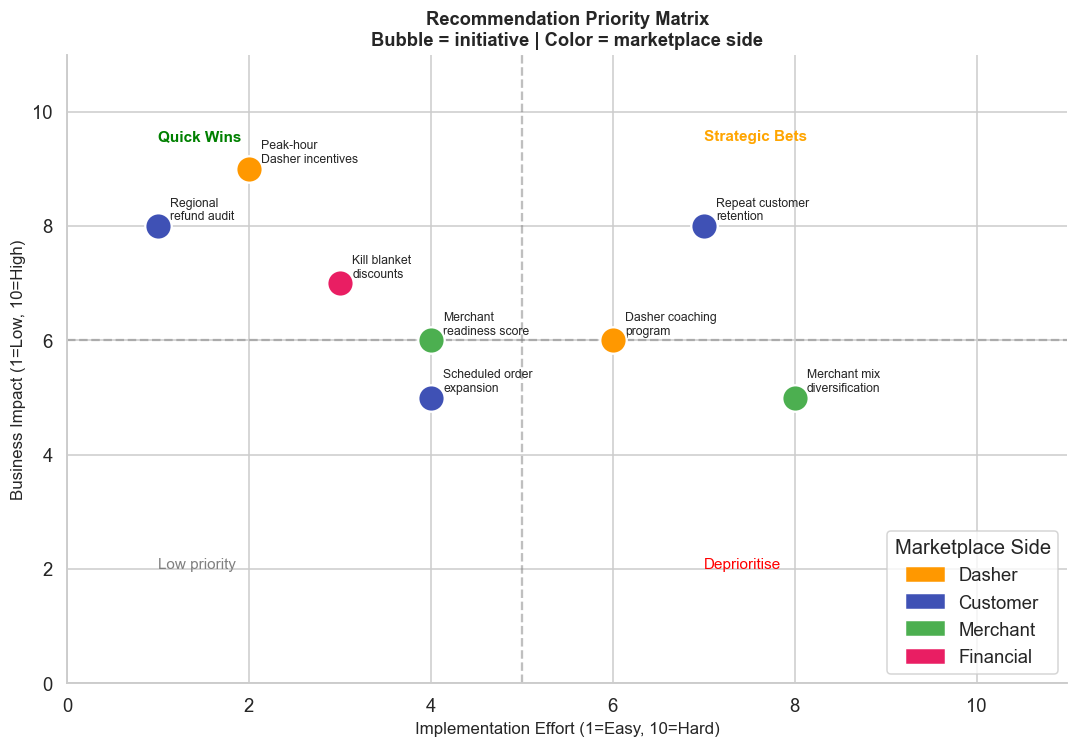

In [25]:
# ── Recommendation Priority Matrix (visual) ──
recs = [
    ('Peak-hour\nDasher incentives', 9, 2, 'Dasher'),
    ('Regional\nrefund audit',        8, 1, 'Customer'),
    ('Kill blanket\ndiscounts',       7, 3, 'Financial'),
    ('Merchant\nreadiness score',     6, 4, 'Merchant'),
    ('Scheduled order\nexpansion',    5, 4, 'Customer'),
    ('Dasher coaching\nprogram',      6, 6, 'Dasher'),
    ('Merchant mix\ndiversification', 5, 8, 'Merchant'),
    ('Repeat customer\nretention',    8, 7, 'Customer'),
]
colors_map = {'Dasher':'#FF9800','Customer':'#3F51B5','Merchant':'#4CAF50','Financial':'#E91E63'}

fig, ax = plt.subplots(figsize=(10, 7))
for label, impact, effort, side in recs:
    ax.scatter(effort, impact, s=300, color=colors_map[side], zorder=5, edgecolors='white', linewidth=1.5)
    ax.annotate(label, (effort, impact), textcoords='offset points', xytext=(8, 4), fontsize=8)

ax.axvline(5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(6, color='gray', linestyle='--', alpha=0.5)
ax.text(1, 9.5, 'Quick Wins', fontsize=10, color='green', fontweight='bold')
ax.text(7, 9.5, 'Strategic Bets', fontsize=10, color='orange', fontweight='bold')
ax.text(1, 2,   'Low priority', fontsize=10, color='gray')
ax.text(7, 2,   'Deprioritise', fontsize=10, color='red')

ax.set_xlabel('Implementation Effort (1=Easy, 10=Hard)', fontsize=11)
ax.set_ylabel('Business Impact (1=Low, 10=High)', fontsize=11)
ax.set_title('Recommendation Priority Matrix\nBubble = initiative | Color = marketplace side', fontsize=12, fontweight='bold')
ax.set_xlim(0, 11); ax.set_ylim(0, 11)

legend_patches = [mpatches.Patch(color=v, label=k) for k,v in colors_map.items()]
ax.legend(handles=legend_patches, loc='lower right', title='Marketplace Side')

plt.tight_layout()
plt.show()

In [26]:
print('Analysis complete. All sections rendered.')
print('\nNotebook covers:')
sections = [
    '  Executive Summary', ' Stated Assumptions',
    '  Data Cleaning & Quality', ' Duplicate Analysis (exact + logical)',
    '  Outlier Detection (IQR + boxplots)', ' Descriptive Statistics (with skew/kurtosis)',
    '  KPI Dashboard (12 KPIs + scorecard)', ' Three-Sided Marketplace (Customer / Dasher / Merchant)',
    '  Demand & Financial Patterns', ' Business Insights', ' Strategic Recommendations + Roadmap',
    '  Priority Matrix visualization',
]
for s in sections: print(s)

Analysis complete. All sections rendered.

Notebook covers:
  Executive Summary
 Stated Assumptions
  Data Cleaning & Quality
 Duplicate Analysis (exact + logical)
  Outlier Detection (IQR + boxplots)
 Descriptive Statistics (with skew/kurtosis)
  KPI Dashboard (12 KPIs + scorecard)
 Three-Sided Marketplace (Customer / Dasher / Merchant)
  Demand & Financial Patterns
 Business Insights
 Strategic Recommendations + Roadmap
  Priority Matrix visualization
